In [ ]:
#Load The Dataset-->
import pandas as pd
df = pd.read_csv("nykaa_campaign_data.csv")

In [ ]:
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

In [ ]:
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.446044,55087.885357,4688.070507,1877.271119,1032.866925,5.158197e+05,377.347068,2.713807,13.784169
std,7.520438,25930.001514,3178.686285,1435.636117,862.496788,4.900121e+05,541.084524,4.493380,6.353125
min,5.000000,10001.000000,202.000000,56.000000,19.000000,6.183000e+03,9.080000,-0.970000,2.600000
25%,11.000000,32680.000000,2110.000000,779.000000,400.000000,1.777060e+05,105.435000,0.040000,8.360000
50%,17.000000,55182.000000,3907.000000,1481.000000,779.000000,3.604360e+05,207.510000,1.240000,13.600000
75%,24.000000,77514.500000,6688.000000,2605.000000,1414.000000,6.874225e+05,428.580000,3.630000,18.855000
max,30.000000,100000.000000,14868.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,74.420000,30.910000


In [ ]:
df.shape

(55555, 16)

In [ ]:
#Check Duplicate Records-->
df.duplicated().sum()

np.int64(0)

In [ ]:
#Convert The Date Column-->
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Campaign_ID       55555 non-null  object        
 1   Campaign_Type     55555 non-null  object        
 2   Target_Audience   55555 non-null  object        
 3   Duration          55555 non-null  int64         
 4   Channel_Used      55555 non-null  object        
 5   Impressions       55555 non-null  int64         
 6   Clicks            55555 non-null  int64         
 7   Leads             55555 non-null  int64         
 8   Conversions       55555 non-null  int64         
 9   Revenue           55555 non-null  int64         
 10  Acquisition_Cost  55555 non-null  float64       
 11  ROI               55555 non-null  float64       
 12  Language          55555 non-null  object        
 13  Engagement_Score  55555 non-null  float64       
 14  Customer_Segment  5555

<Axes: >

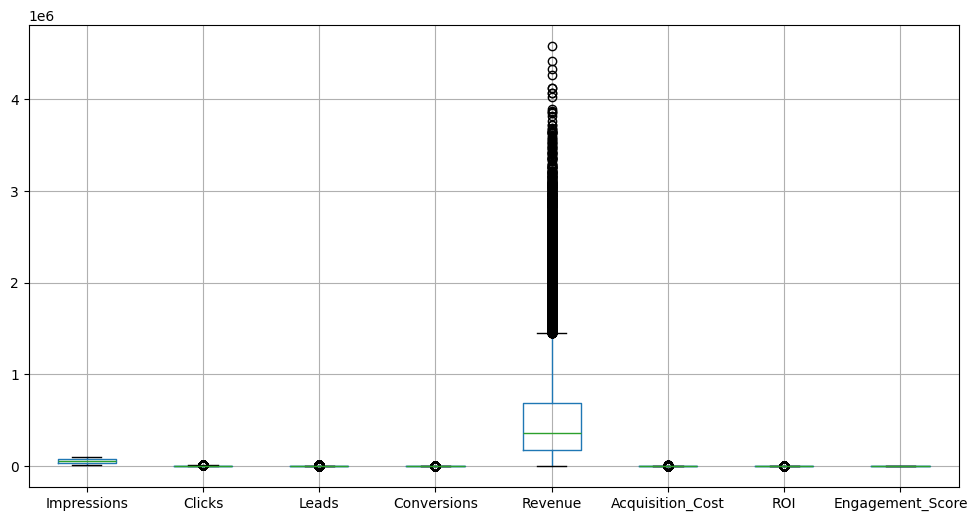

In [ ]:
#Check For Outliers-->
numeric_columns = [
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Revenue",
    "Acquisition_Cost",
    "ROI",
    "Engagement_Score"
]

df[numeric_columns].boxplot(figsize=(12,6))

In [ ]:
#Check For Invalid Values-->
(df["Impressions"] < 0).sum()

(df["Clicks"] < 0).sum()

(df["Revenue"] < 0).sum()

np.int64(0)

In [ ]:
#Create New Time Columns-->
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month_name()

df["Month_Number"] = df["Date"].dt.month

df["Quarter"] = df["Date"].dt.quarter

In [ ]:
#calculate KPIs-->
df["CTR"] = (df["Clicks"] / df["Impressions"]) * 100

df["Conversion_Rate"] = (
    df["Conversions"] / df["Clicks"]
) * 100

In [ ]:
#Save the Cleaned Dataset-->
df.to_csv(
    "cleaned_marketing_data.csv",
    index=False
)

##Stage-3: Marketing KPI Analysis

In [ ]:
#Load the cleaned dataset-->
df = pd.read_csv("cleaned_marketing_data.csv")
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,...,Language,Engagement_Score,Customer_Segment,Date,Year,Month,Month_Number,Quarter,CTR,Conversion_Rate
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,...,Hindi,20.98,College Students,2025-04-29,2025,April,4,2,10.649782,38.255361
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,...,Hindi,7.24,College Students,2025-04-06,2025,April,4,2,3.617608,40.861186
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,...,English,25.03,College Students,2025-01-14,2025,January,1,1,14.044799,34.601283
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,...,Hindi,13.15,College Students,2025-06-04,2025,June,6,2,9.547858,11.256389
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,...,Hindi,7.29,Tier 2 City Customers,2024-12-29,2024,December,12,4,3.863901,33.609404


In [ ]:
#Calculate Overall Marketing KPIs-->
total_campaigns = df["Campaign_ID"].nunique()

total_impressions = df["Impressions"].sum()

total_clicks = df["Clicks"].sum()

total_leads = df["Leads"].sum()

total_conversions = df["Conversions"].sum()

total_revenue = df["Revenue"].sum()

total_cost = df["Acquisition_Cost"].sum()

average_roi = df["ROI"].mean()

average_engagement = df["Engagement_Score"].mean()

print("Total Campaigns:", total_campaigns)
print("Total Impressions:", total_impressions)
print("Total Clicks:", total_clicks)
print("Total Leads:", total_leads)
print("Total Conversions:", total_conversions)
print("Total Revenue:", total_revenue)
print("Total Cost:", total_cost)
print("Average ROI:", average_roi)
print("Average Engagement:", average_engagement)

Total Campaigns: 55555
Total Impressions: 3060407471
Total Clicks: 260445757
Total Leads: 104291797
Total Conversions: 57380922
Total Revenue: 28656364282
Total Cost: 20963516.36
Average ROI: 2.713806858068581
Average Engagement: 13.78416884168842


In [ ]:
#Click Through Rate (CTR) Analysis-->
average_ctr = df["CTR"].mean()
highest_ctr = df["CTR"].max()
lowest_ctr = df["CTR"].min()
top_ctr = (
    df.groupby("Campaign_ID")["CTR"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(top_ctr)

Campaign_ID
NY-CMP-40541    14.999354
NY-CMP-48526    14.999172
NY-CMP-25290    14.998770
NY-CMP-35286    14.998220
NY-CMP-19105    14.998146
NY-CMP-32303    14.997928
NY-CMP-37929    14.997781
NY-CMP-49174    14.997547
NY-CMP-1286     14.997189
NY-CMP-22381    14.997172
Name: CTR, dtype: float64


In [ ]:
#Conversion Rate Analysis-->
average_conversion = df["Conversion_Rate"].mean()
highest_conversion = df["Conversion_Rate"].max()
top_conversion = (
    df.groupby("Campaign_ID")["Conversion_Rate"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(top_conversion)

Campaign_ID
NY-CMP-25102    47.742624
NY-CMP-40104    47.676874
NY-CMP-27298    47.603196
NY-CMP-22426    47.600000
NY-CMP-45474    47.521729
NY-CMP-42589    47.494812
NY-CMP-39619    47.476568
NY-CMP-13778    47.469220
NY-CMP-36396    47.450782
NY-CMP-1958     47.386478
Name: Conversion_Rate, dtype: float64


In [ ]:
#ROI Analysis-->
print(df["ROI"].describe())
top_roi = (
    df.groupby("Campaign_ID")["ROI"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
print(top_roi)

bottom_roi = (
    df.groupby("Campaign_ID")["ROI"]
      .mean()
      .sort_values()
      .head(10)
)
print(bottom_roi)

count    55555.000000
mean         2.713807
std          4.493380
min         -0.970000
25%          0.040000
50%          1.240000
75%          3.630000
max         74.420000
Name: ROI, dtype: float64
Campaign_ID
NY-CMP-13007    74.42
NY-CMP-22689    66.32
NY-CMP-49715    65.00
NY-CMP-26356    64.14
NY-CMP-39329    59.64
NY-CMP-2174     55.27
NY-CMP-51204    54.74
NY-CMP-5736     53.70
NY-CMP-35197    52.53
NY-CMP-24042    52.45
Name: ROI, dtype: float64
Campaign_ID
NY-CMP-9361    -0.97
NY-CMP-24406   -0.97
NY-CMP-16583   -0.96
NY-CMP-55748   -0.96
NY-CMP-24680   -0.96
NY-CMP-53545   -0.96
NY-CMP-36224   -0.96
NY-CMP-41110   -0.96
NY-CMP-14988   -0.96
NY-CMP-11980   -0.96
Name: ROI, dtype: float64


In [ ]:
#Customer Engagement Analysis-->
engagement = (
    df.groupby("Campaign_Type")["Engagement_Score"]
      .mean()
      .sort_values(ascending=False)
)

print(engagement)

channel_engagement = (
    df.groupby("Channel_Used")["Engagement_Score"]
      .mean()
      .sort_values(ascending=False)
)

print(channel_engagement)

Campaign_Type
Influencer      13.861539
Social Media    13.845957
Paid Ads        13.751833
Email           13.747823
SEO             13.713328
Name: Engagement_Score, dtype: float64
Channel_Used
Facebook, YouTube, Email       15.045745
Instagram, WhatsApp, Google    14.856463
Email, WhatsApp, Facebook      14.776828
WhatsApp, Facebook             14.774341
Instagram, Google, Email       14.688137
                                 ...    
WhatsApp, Facebook, Google     12.810559
Facebook, Google, WhatsApp     12.695063
WhatsApp, YouTube, Facebook    12.680671
YouTube, WhatsApp, Google      12.493293
YouTube, Google, Facebook      12.155541
Name: Engagement_Score, Length: 156, dtype: float64


In [ ]:
#Customer reach Analysis-->

#Campaign reach:
reach = (
    df.groupby("Campaign_Type")["Impressions"]
      .sum()
      .sort_values(ascending=False)
)
print(reach)

#Channel Reach-->
channel_reach = (
    df.groupby("Channel_Used")["Impressions"]
      .sum()
      .sort_values(ascending=False)
)
print(channel_reach)

Campaign_Type
Social Media    614719895
Influencer      613633772
Paid Ads        613127804
SEO             610436103
Email           608489897
Name: Impressions, dtype: int64
Channel_Used
Instagram                       174406008
YouTube                         172516499
WhatsApp                        172054940
Email                           169904207
Google                          168501539
                                  ...    
WhatsApp, Google, Instagram       6970927
WhatsApp, YouTube, Email          6775059
Google, Facebook, Instagram       6752245
YouTube, WhatsApp, Instagram      6490436
Email, YouTube, Facebook          5864171
Name: Impressions, Length: 156, dtype: int64


In [ ]:
#Revenue Analysis-->
revenue_campaign = (
    df.groupby("Campaign_Type")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(revenue_campaign)

#Revenue By Channel:
channel_revenue = (
    df.groupby("Channel_Used")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(channel_revenue)

Campaign_Type
Influencer      5769064044
Social Media    5751837620
Paid Ads        5751468983
SEO             5698831847
Email           5685161788
Name: Revenue, dtype: int64
Channel_Used
Instagram                       1639493563
WhatsApp                        1615380939
YouTube                         1597611646
Email                           1587734385
Google                          1586013727
                                   ...    
WhatsApp, Google, Instagram       62816889
YouTube, WhatsApp, Instagram      61106820
WhatsApp, YouTube, Google         60253318
Email, YouTube, Facebook          58148065
Google, Instagram, Facebook       58059912
Name: Revenue, Length: 156, dtype: int64


In [ ]:
#Cost Analysis-->
cost_channel = (
    df.groupby("Channel_Used")["Acquisition_Cost"]
      .sum()
      .sort_values(ascending=False)
)

print(cost_channel)

Channel_Used
YouTube                        1253669.14
Google                         1201528.71
WhatsApp                       1182375.14
Instagram                      1175344.99
Facebook                       1152062.11
                                  ...    
Google, Facebook, Instagram      42389.16
Instagram, Email, Google         42389.02
YouTube, Google, Email           42288.09
Email, YouTube, Facebook         38187.11
Google, WhatsApp, YouTube        34714.25
Name: Acquisition_Cost, Length: 156, dtype: float64


In [ ]:
#Lead Analysis-->
lead_channel = (
    df.groupby("Channel_Used")["Leads"]
      .sum()
      .sort_values(ascending=False)
)

print(lead_channel)

Channel_Used
Instagram                       5941320
YouTube                         5939026
WhatsApp                        5902521
Email                           5799945
Google                          5744089
                                 ...   
WhatsApp, YouTube, Google        230996
WhatsApp, Email, YouTube         228914
Email, YouTube, Instagram        224556
YouTube, WhatsApp, Instagram     212240
Email, YouTube, Facebook         197390
Name: Leads, Length: 156, dtype: int64


In [ ]:
#Conversion Analysis-->
conversion_channel = (
    df.groupby("Channel_Used")["Conversions"]
      .sum()
      .sort_values(ascending=False)
)

print(conversion_channel)

Channel_Used
Instagram                       3294211
YouTube                         3242976
WhatsApp                        3239706
Email                           3178048
Google                          3139859
                                 ...   
WhatsApp, Google, Instagram      124911
Email, YouTube, Instagram        124323
WhatsApp, Email, YouTube         124083
YouTube, WhatsApp, Instagram     118114
Email, YouTube, Facebook         113318
Name: Conversions, Length: 156, dtype: int64


In [ ]:
#Monthly KPI Analysis-->

#Revenue By Month:
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
)
print(monthly_revenue)

#ROI By Month:
monthly_roi = (
    df.groupby("Month")["ROI"]
      .mean()
)
print(monthly_roi)

#Conversions By Month:
monthly_conversion = (
    df.groupby("Month")["Conversions"]
      .sum()
)
print(monthly_conversion)

Month
April        2439364737
August       2597876736
December     2586353806
February     2333105678
January      2521812438
July         2630226313
June          906477811
March        2570717938
May          2572782370
November     2523763004
October      2583203421
September    2390680030
Name: Revenue, dtype: int64
Month
April        2.644182
August       2.767831
December     2.712556
February     2.758309
January      2.654092
July         2.809377
June         2.599144
March        2.733766
May          2.777322
November     2.748278
October      2.616831
September    2.672931
Name: ROI, dtype: float64
Month
April        4951704
August       5187225
December     5148613
February     4716303
January      5028996
July         5224622
June         1845587
March        5139085
May          5082964
November     5070569
October      5193529
September    4791725
Name: Conversions, dtype: int64


In [ ]:
#Customer Segment Analysis-->
segment_revenue = (
    df.groupby("Customer_Segment")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)
print(segment_revenue)

#ROI By Customer Segment:
segment_roi = (
    df.groupby("Customer_Segment")["ROI"]
      .mean()
      .sort_values(ascending=False)
)
print(segment_roi)

Customer_Segment
Working Women            5811927015
College Students         5799502690
Premium Shoppers         5709910379
Tier 2 City Customers    5691846274
Youth                    5643177924
Name: Revenue, dtype: int64
Customer_Segment
Working Women            2.771055
Premium Shoppers         2.720461
College Students         2.699205
Tier 2 City Customers    2.699197
Youth                    2.679097
Name: ROI, dtype: float64


In [ ]:
#Campaign Type Analysis-->
campaign_analysis = (
    df.groupby("Campaign_Type")[[
        "Revenue",
        "ROI",
        "Conversions",
        "Engagement_Score"
    ]]
    .mean()
)
print(campaign_analysis)

                     Revenue       ROI  Conversions  Engagement_Score
Campaign_Type                                                        
Email          511623.631030  2.682663  1028.236681         13.747823
Influencer     518148.378301  2.699687  1038.613167         13.861539
Paid Ads       517404.550468  2.722275  1027.849316         13.751833
SEO            514381.428559  2.709630  1026.264916         13.713328
Social Media   517530.827785  2.754784  1043.339482         13.845957
